# Part0: Model training on the PerturbFISH dataset

# Package loading and path setting

In [1]:
import sys, os
working_dir = "D:/CellFlowMap/SpiderNet_proj/SpiderNet_proj/"
sys.path.append("working_dir")
##Package import
import os
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import time
import json
import torch
from SpiderNet.model import *
from SpiderNet.utils import *
from matplotlib.lines import Line2D
import scipy.stats as stats
cuda_available = torch.cuda.is_available()
if cuda_available:
    # num_gpus = torch.cuda.device_count()
    # print(f"Number of GPUs available: {num_gpus}")
    # for i in range(num_gpus):
    #     print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    ##
    device = "cuda"
else:
    # print("No GPU available, using CPU instead.")
    device = "cpu"

D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
D:\CellFlowMap\SpiderNet_proj\SpiderNet_proj\.venv\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070


# Hyperparameter Setup

In [2]:

# Version
Version_cur = "V1"

# Graph neighborhood size
num_neigh = 10   # typical values: 4, 5, 8, 10

# Factorization mode
Factor_mode = 'cell_class'  # options: 'cell_class', 'NMF'
dim_intri = 25 if Factor_mode == "NMF" else None

# Environmental dimension
dim_envir = 20   # examples: 8, 10, 12, 20, 30, None

# Model capacity
hidden_channels = 64   # examples: 32, 128, 256

# Optimization
lr = 1e-4
weight_decay = 1e-5
loss_fn = 'mse'

# Training schedule
warmup = 2000          # warmup steps before learning rate decay
max_epoch = 20000      # total training epochs

# Loss weighting
LR_loss_weight = 1     # relative weight for LR reconstruction loss

# Correlation thresholds
threshold_crosscorr = 0.1
numtop_crosscorr = 10
spearcorr_use_rowmax_threshold = 0.2

# Ligand–Receptor pair subsampling
if_subsetLRpair = False   # True → random subset for training
num_subsetLRpair_ratio = 0.80

# Cell–cell connection proportion threshold
CC_prop_threshold = 0.2  # filter LR pairs by coverage proportion

# Job parallelization
n_jobs = 5

# Initial regression type
Initial_regression = "Linear"   # or "Lasso"

# Gene selection
nHVG = 1000       # highly variable genes for training
nHVG_LR = 2000    # highly variable genes for LR module

# Meta-interaction aggregation threshold
MIlevel_agg_threshold = 0.6     # typical range: 0.4–0.7


# File Path Setup

In [3]:
# Base directories
data_path_main = "D:/CellFlowMap/PerturbFish/Data/perturb_fish/"
save_path_main = data_path_main.replace("Data/", "Results/")

# Input ligand–receptor databases
ligand_receptor_filedir_cellchatdb = os.path.join(data_path_main, "Human_LR_pairs_Cellchatdb.csv")
ligand_receptor_filedir_scSeqComm = os.path.join(data_path_main, "Human_LR_pairs_scSeqComm.csv")

# Current run directory (versioned)
data_path_main_cur = data_path_main
save_path_main_cur = os.path.join(save_path_main, Version_cur)
os.makedirs(save_path_main_cur, exist_ok=True)

# Define subdirectory name pattern
subset_tag = "_subsetLRpair" if if_subsetLRpair else ""
result_tag = f"SpiderNet_Result_Mode_{Factor_mode}_selfsetdim{dim_envir}{subset_tag}"

# Define output paths
file_savepath_main = os.path.join(save_path_main_cur, result_tag)
if not file_savepath_main.endswith(os.sep):
    file_savepath_main += os.sep
print("file_savepath_main:", file_savepath_main)
file_savepath_MI_main = os.path.join(file_savepath_main, "MetaInteraction")
file_savepath_model_main = os.path.join(file_savepath_main, "Model")
if not file_savepath_MI_main.endswith(os.sep):
    file_savepath_MI_main += os.sep
if not file_savepath_model_main.endswith(os.sep):
    file_savepath_model_main += os.sep
# Create directories if they don't exist
for path in [file_savepath_main, file_savepath_MI_main, file_savepath_model_main]:
    os.makedirs(path, exist_ok=True)


file_savepath_main: D:/CellFlowMap/PerturbFish/Results/perturb_fish/V1\SpiderNet_Result_Mode_cell_class_selfsetdim20\


# Load the data

## Preprocessing the raw data in SpiderNet data format

In [4]:
subprocess.run([
    sys.executable, "-m", "SpiderNet.dataloading_PerturbFISH",
    data_path_main,
    str(nHVG), str(nHVG_LR),
    ligand_receptor_filedir_cellchatdb, ligand_receptor_filedir_scSeqComm,
    str(num_neigh), str(CC_prop_threshold),
    save_path_main, file_savepath_main,
    str(if_subsetLRpair), str(num_subsetLRpair_ratio)
])

CompletedProcess(args=['D:\\CellFlowMap\\SpiderNet_proj\\SpiderNet_proj\\.venv\\Scripts\\python.exe', '-m', 'SpiderNet.dataloading_PerturbFISH', 'D:/CellFlowMap/PerturbFish/Data/perturb_fish/', '1000', '2000', 'D:/CellFlowMap/PerturbFish/Data/perturb_fish/Human_LR_pairs_Cellchatdb.csv', 'D:/CellFlowMap/PerturbFish/Data/perturb_fish/Human_LR_pairs_scSeqComm.csv', '10', '0.2', 'D:/CellFlowMap/PerturbFish/Results/perturb_fish/', 'D:/CellFlowMap/PerturbFish/Results/perturb_fish/V1\\SpiderNet_Result_Mode_cell_class_selfsetdim20\\', 'False', '0.8'], returncode=0)

## Load the processed SpiderNet data

In [5]:
adata_copy_path = file_savepath_main + "adata_all.h5ad"
adata_copy = sc.read_h5ad(adata_copy_path, backed='r')
SpiderNet_data_pyg_list = pd.read_pickle(file_savepath_main + 'SpiderNet_data_pyg_list.pkl')
LR_list = pd.read_pickle(file_savepath_main + 'LR_list.pkl')
batch_cell_unique = pd.read_pickle(file_savepath_main + 'batch_cell_unique.pkl')
genenames_train = pd.read_pickle(file_savepath_main + 'genenames_train.pkl')
LR_list_cellchatdb = pd.read_pickle(file_savepath_main + 'LR_list_cellchatdb.pkl')
LR_meta_cellchatdb = pd.read_pickle(file_savepath_main + 'LR_meta_cellchatdb.pkl')
batch_cell_path = file_savepath_main + 'batch_cell.pkl'
batch_cell = pd.read_pickle(batch_cell_path)
adata_list_path = file_savepath_main + 'adata_list.pkl'
adata_list = pd.read_pickle(adata_list_path)
LR_loading_pathway_show_pathway = file_savepath_main + "LR_loading_pathway_show.csv"


## Check whether the data is loaded correctly

In [6]:
check_df = pd.DataFrame({"Adata": [adata_list[i].obs.shape[0] for i in range(len(adata_list))], "Edge_max": [torch.max(SpiderNet_data_pyg_list[i]['edge_index']).numpy() for i in range(len(adata_list))]})
if not all(check_df["Adata"] == check_df["Edge_max"] + 1):
    print("Dataloading issue detected: edge_max and sample size are misaligned!")
    print(check_df.loc[check_df["Adata"] != check_df["Edge_max"] + 1])
del check_df

## Move data to device

In [7]:
for batch_cell_unique_cur_index in range(len(batch_cell_unique)):
    SpiderNet_data_pyg_list[batch_cell_unique_cur_index] = SpiderNet_data_pyg_list[batch_cell_unique_cur_index].to(device)


# Define and train the SpiderNet model

## Model definition

In [8]:
if Factor_mode == "NMF":
    model = SpiderNet_model(num_gene=genenames_train.shape[0],
                          num_LR=len(LR_list),
                          hidden_channels=hidden_channels,
                          Factor_mode=Factor_mode,
                          dim_intri=dim_intri,
                          dim_envir=dim_envir)
    model_config = {
    "num_gene": genenames_train.shape[0],
    "num_LR": len(LR_list),
    "hidden_channels": hidden_channels,
    "Factor_mode": Factor_mode,
    "dim_intri": dim_intri,
    "dim_envir": dim_envir
}
else:
    model = SpiderNet_model(num_gene=genenames_train.shape[0],
                          num_LR=len(LR_list),
                          hidden_channels=hidden_channels,
                          Factor_mode=Factor_mode,
                          dim_intri=SpiderNet_data_pyg_list[0][Factor_mode + '_onehot'].shape[1],
                          dim_envir=dim_envir)
    model_config = {
    "num_gene": genenames_train.shape[0],
    "num_LR": len(LR_list),
    "hidden_channels": hidden_channels,
    "Factor_mode": Factor_mode,
    "dim_intri": SpiderNet_data_pyg_list[0][Factor_mode + '_onehot'].shape[1],
    "dim_envir": dim_envir
}
model = model.to(device)


with open(file_savepath_model_main + "SpiderNet_model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)


In [9]:
print("Model Summary:")
for name, param in model.named_parameters():
    print(name, param.size(), "Trainable:", param.requires_grad)

Model Summary:
Loading_intrinsic_ori torch.Size([3, 154]) Trainable: True
loading_receiver_ori torch.Size([20, 154]) Trainable: True
loading_sender_ori torch.Size([20, 154]) Trainable: True
loading_LR_ori torch.Size([20, 126]) Trainable: True
enc_factor_envir_pre_receiver.0.weight torch.Size([128, 154]) Trainable: True
enc_factor_envir_pre_receiver.0.bias torch.Size([128]) Trainable: True
enc_factor_envir_pre_receiver.2.weight torch.Size([64, 128]) Trainable: True
enc_factor_envir_pre_receiver.2.bias torch.Size([64]) Trainable: True
enc_factor_envir_pre_sender.0.weight torch.Size([128, 154]) Trainable: True
enc_factor_envir_pre_sender.0.bias torch.Size([128]) Trainable: True
enc_factor_envir_pre_sender.2.weight torch.Size([64, 128]) Trainable: True
enc_factor_envir_pre_sender.2.bias torch.Size([64]) Trainable: True
enc_factor_envir.0.weight torch.Size([128, 128]) Trainable: True
enc_factor_envir.0.bias torch.Size([128]) Trainable: True
enc_factor_envir.2.weight torch.Size([20, 128]) Tr

In [10]:
trainable, non_trainable = count_parameters(model)
print("Total trainable parameters:", trainable)
print("Total non-trainable parameters:", non_trainable)

Total trainable parameters: 84426
Total non-trainable parameters: 0


## Model training

In [11]:
##Check if there is existing trained model
if os.path.exists(file_savepath_model_main + 'model_epoch' + str(max_epoch - 1) + '.pth'):
    print("Loading existing model from epoch", max_epoch - 1)
    model.load_state_dict(torch.load(file_savepath_model_main + 'model_epoch' + str(max_epoch - 1) + '.pth'))
    # ## load the SpiderNet_data_pyg
    # SpiderNet_data_pyg_list = torch.load(file_savepath_main + "SpiderNet_data_pyg_list.pth")
else:
    ##Obtain the initial object
    print("Initialization start.")
    time_initial_start = time.time()
    if Factor_mode == "NMF":
        Initial_dict = Initial_model(SpiderNet_data_pyg_list, dim_envir=dim_envir,
                                     Factor_mode=Factor_mode, dim_intri=dim_intri,
                                     n_jobs=10, Initial_regression=Initial_regression,
                                     if_extend = False,
                                     threshold_crosscorr=threshold_crosscorr,
                                     numtop_crosscorr=numtop_crosscorr,
                                     spearcorr_use_rowmax_threshold=spearcorr_use_rowmax_threshold)
    else:
        Initial_dict = Initial_model(SpiderNet_data_pyg_list, dim_envir=dim_envir,
                                     Factor_mode=Factor_mode, dim_intri=None,
                                     n_jobs=10, Initial_regression=Initial_regression,
                                     if_extend = False,
                                     threshold_crosscorr=threshold_crosscorr,
                                     numtop_crosscorr=numtop_crosscorr,
                                     spearcorr_use_rowmax_threshold=spearcorr_use_rowmax_threshold)
    time_initial_end = time.time()
    time_initial_cost = time_initial_end - time_initial_start
    print("Initialization Finish.")
    print(f"Initialization time cost: {time_initial_cost:.2f} seconds")

    ##
    model_exist = os.listdir(file_savepath_model_main)
    if len(model_exist) > 0:
        model_exist_epoch = np.array([i.replace('model_epoch', '').replace('.pth', '') for i in model_exist]).astype(
            int)
        maxepoch_model = model_exist[np.argmax(model_exist_epoch)]
        ##
        print("Loading existing model:", maxepoch_model)
        model.load_state_dict(torch.load(file_savepath_model_main + maxepoch_model))
        ##Set the warmup to 0
        warmup = 0
        print("No need to initialize the model again")
        max_epoch = max_epoch - int(maxepoch_model.replace('model_epoch', '').replace('.pth', ''))
    ##Fit the model
    start_time = time.time()
    ##
    model.fit(SpiderNet_data_pyg_list=SpiderNet_data_pyg_list,
              device='cuda',
              optim_type='adam',
              lr=lr,
              weight_decay=weight_decay,
              LR_loss_weight=LR_loss_weight,
              warmup=warmup,
              max_epoch=max_epoch,
              loss_fn=loss_fn,
              Initial_dict=Initial_dict,
              file_savepath_model_main = file_savepath_model_main)
    #
    end_time = time.time()
    execution_time = end_time - start_time
    execution_time_minutes = execution_time / 60
    print("Execution time in minutes:", execution_time_minutes)

Loading existing model from epoch 19999


In [12]:
##Save the SpiderNet_data_pyg
if not os.path.exists(file_savepath_model_main + 'model_epoch' + str(max_epoch - 1) + '.pth'):
    torch.save(SpiderNet_data_pyg_list, file_savepath_main + "SpiderNet_data_pyg_list.pth")


## Model evaluation: obtain the inferred meta-interactions and loadings

In [13]:
model.eval()

SpiderNet_model(
  (dropout_fun): Dropout(p=0.1, inplace=False)
  (Relu): ReLU()
  (Sigmoid): Sigmoid()
  (enc_factor_envir_pre_receiver): Sequential(
    (0): Linear(in_features=154, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (enc_factor_envir_pre_sender): Sequential(
    (0): Linear(in_features=154, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (enc_factor_envir): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=20, bias=True)
  )
)

### Inferred meta-interactions

In [14]:
Factor_envir_list = []
for batch_index_cur in range(len(SpiderNet_data_pyg_list)):
    _, _, _, Loading_intrinsic, Factor_envir_curbatch, loading_receiver, loading_sender, loading_LR = model(SpiderNet_data_pyg_list[batch_index_cur])
    Factor_envir_list.append(Factor_envir_curbatch.cpu().detach().numpy().astype(np.float32))
Factor_envir_use = np.vstack(Factor_envir_list)

### LR Loading

In [15]:
loading_LR_use = loading_LR.cpu().detach().numpy().astype(np.float32)

### Sender/receiver gene loading (regulator and target gene loading)

In [16]:
loading_receiver_use = loading_receiver.cpu().detach().numpy().astype(np.float32)
loading_sender_use = loading_sender.cpu().detach().numpy().astype(np.float32)

### Normalize the inferred meta-interactions and loadings

In [17]:
Factor_envir_use_max = np.max(Factor_envir_use, axis=0)
loading_LR_use = loading_LR_use * Factor_envir_use_max[:,np.newaxis]
loading_receiver_use = loading_receiver_use * Factor_envir_use_max[:,np.newaxis]
loading_sender_use = loading_sender_use * Factor_envir_use_max[:,np.newaxis]
Factor_envir_use = Factor_envir_use / (Factor_envir_use_max[np.newaxis,:] + 1e-10)
for i in range(len(Factor_envir_list)):
    Factor_envir_list[i] = Factor_envir_list[i] / (Factor_envir_use_max[np.newaxis,:] + 1e-10)


### Check the shapes of the inferred matricee

In [18]:
print("Factor_envir_use shape:", Factor_envir_use.shape)
print("loading_LR_use shape:", loading_LR_use.shape)
print("loading_receiver_use shape:", loading_receiver_use.shape)
print("loading_sender_use shape:", loading_sender_use.shape)

Factor_envir_use shape: (1544180, 20)
loading_LR_use shape: (20, 126)
loading_receiver_use shape: (20, 154)
loading_sender_use shape: (20, 154)


### Save the inferred meta-interactions and loadings

In [19]:
loading_receiver_use_df = pd.DataFrame(loading_receiver_use, index=["MI" + str(i + 1) for i in range(loading_receiver_use.shape[0])],
                                        columns=adata_list[0].var_names)
loading_sender_use_df = pd.DataFrame(loading_sender_use, index=["MI" + str(i + 1) for i in range(loading_sender_use.shape[0])],
                                        columns=adata_list[0].var_names)
##Save the loading_receiver_use_df as csv
loading_receiver_use_df_path = file_savepath_main + "loading_receiver_use.csv"
loading_receiver_use_df.to_csv(loading_receiver_use_df_path, index=True)
##Save the loading_sender_use_df as csv
loading_sender_use_df_path = file_savepath_main + "loading_sender_use.csv"
loading_sender_use_df.to_csv(loading_sender_use_df_path, index=True)

##Save the Factor_envir_use and Factor_envir_list
Factor_envir_use_path = file_savepath_main + "Factor_envir_use.npy"
np.save(Factor_envir_use_path, Factor_envir_use)
##save the Factor_envir_list
import pickle
Factor_envir_list_path = file_savepath_main + "Factor_envir_list.pkl"
with open(Factor_envir_list_path, 'wb') as f:
    pickle.dump(Factor_envir_list, f)
    
loading_LR_use_path = file_savepath_main + "loading_LR_use.npy"
np.save(loading_LR_use_path, loading_LR_use)

# Show the in situ plot of cell type and perturbation

## Spatial plot by cell type

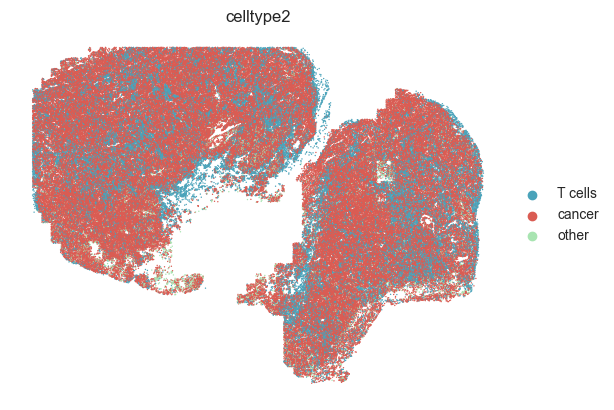

In [20]:
celltype_colors = {
    "T cells": "#4AA3BA",   # blue
    "cancer": "#DA5C53",    # red
    "other": "#A8E4B1"      # green
}

# Plot spatial distribution of cell types
sc.pl.embedding(
    adata_copy,
    basis="spatial",
    color="celltype2",
    palette=[celltype_colors[c] for c in np.unique(adata_copy.obs["celltype2"])],
    size=4,
    frameon=False,
    title="celltype2",
    show=False
)

plt.savefig(
    file_savepath_main + "spatial_celltype2_distribution.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()
plt.close()


## Assign perturbation groups

C:\Users\junji\AppData\Local\Temp\ipykernel_7268\651930568.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10_colors = [plt.cm.get_cmap("tab10")(i) for i in range(10)]


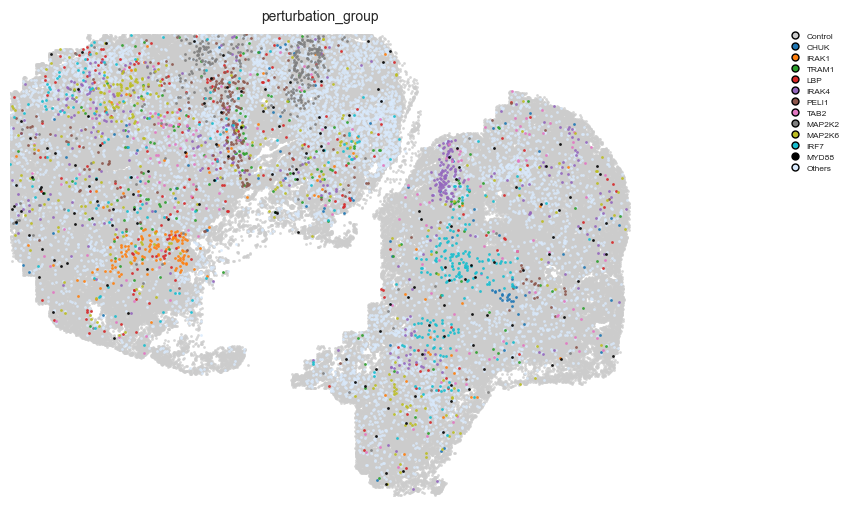

In [21]:
perturbed_genes = [
    "CHUK", "IRAK1", "TRAM1", "LBP", "IRAK4",
    "PELI1", "TAB2", "MAP2K2", "MAP2K6", "IRF7", "MYD88"
]

perturb_raw = adata_copy.obs["perturbation"].astype(str)

def assign_group(p):
    if p == "nan" or p.strip() == "":
        return "Control"
    parts = p.split("_")
    for g in perturbed_genes:
        if g in parts:
            return g
    return "Others"

adata_copy.obs["perturbation_group"] = perturb_raw.apply(assign_group)
adata_copy.obs["perturbation_group"] = pd.Categorical(
    adata_copy.obs["perturbation_group"],
    categories=["Control"] + perturbed_genes + ["Others"],
    ordered=True
)

# ============================================================
# Spatial plot by perturbation group
# ============================================================

# perturbation_order = ["Control"] + perturbed_genes + ["Others"]
# tab10_colors = [plt.cm.get_cmap("tab10")(i) for i in range(10)]
# palette = ["#CCCCCC"] + tab10_colors + ["#D9EAFD"]  # gray–tab10–light blue
# color_map = dict(zip(perturbation_order, palette))
perturbation_order = ["Control"] + perturbed_genes + ["Others"]
tab10_colors = [plt.cm.get_cmap("tab10")(i) for i in range(10)]
palette = ["#CCCCCC"] + tab10_colors + ['black'] +["#D9EAFD"]  # gray–tab10–light blue
color_map = dict(zip(perturbation_order, palette))

coords = adata_copy.obsm["spatial"]
xlim, ylim = (coords[:, 0].min(), coords[:, 0].max()), (coords[:, 1].min(), coords[:, 1].max())

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.axis("off")

# Plot control and others first (background)
for group in ["Control", "Others"]:
    subset = adata_copy[adata_copy.obs["perturbation_group"] == group]
    ax.scatter(
        subset.obsm["spatial"][:, 0],
        subset.obsm["spatial"][:, 1],
        s=4, color=color_map[group], alpha=0.8, linewidths=0
    )

# Overlay individual perturbed groups
for g in perturbed_genes:
    mask = adata_copy.obs["perturbation_group"] == g
    if mask.sum() == 0:
        continue
    ax.scatter(
        adata_copy.obsm["spatial"][mask, 0],
        adata_copy.obsm["spatial"][mask, 1],
        s=4, color=color_map[g], alpha=0.9, linewidths=0
    )

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='none', label=g,
           markerfacecolor=color_map[g], markersize=5)
    for g in perturbation_order
]
ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(1.35, 1.02),
    frameon=False,
    ncol=1,
    fontsize=6,
    handletextpad=0.4
)

plt.title("perturbation_group", fontsize=10, pad=10)
plt.savefig(
    file_savepath_main + "spatial_perturbation_group_distribution_matched.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()
plt.close()


#  LR Loading enrichment analysis

TGFb: 5 LR pairs
FN1: 8 LR pairs
LAMININ: 6 LR pairs
TENASCIN: 3 LR pairs


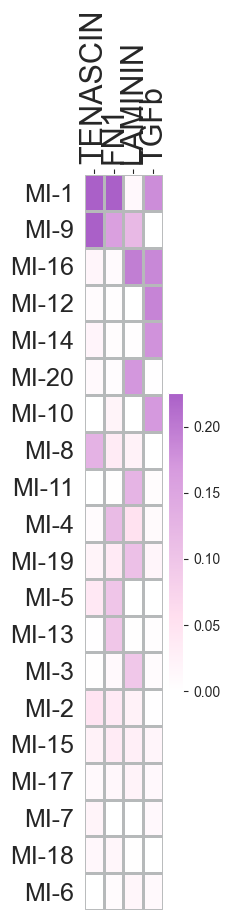

In [22]:
from SpiderNet.Loading_LR_enrichment_analysis import run_analysis

run_analysis(
    loading_LR_use_path = file_savepath_main + "loading_LR_use.npy",
    lr_list_path = file_savepath_main + "LR_list.pkl",
    lr_list_cellchatdb_path = file_savepath_main + "LR_list_cellchatdb.pkl",
    lr_meta_cellchatdb_path = file_savepath_main + "LR_meta_cellchatdb.pkl",
    Factor_envir_use_path = file_savepath_main + "Factor_envir_use.npy",
    file_savepath_main = file_savepath_main,
    show = True
)
